In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
from scipy.stats import gaussian_kde

from mplsoccer import VerticalPitch, Sbopen, FontManager

# data parser, fonts and path effects for giving the font an edge
parser = Sbopen()
pitch = VerticalPitch(goal_type='box', line_alpha=0.5, goal_alpha=0.5)
fm_rubik = FontManager('https://raw.githubusercontent.com/google/fonts/main/ofl/'
                       'rubikmonoone/RubikMonoOne-Regular.ttf')

In [18]:
event, related, freeze, tactics = parser.event(3857283)

# Check the actual team names in the data
print(event['team_name'].unique())  # Run this first to confirm exact team name

# Starting XI for Morocco (match exact team name from StatsBomb)
starting_xi_event = event.loc[
    ((event['type_name'] == 'Starting XI') &
     (event['team_name'] == 'Morocco')),  # Fixed: 'morocco' -> 'Morocco'
    ['id', 'tactics_formation']
]

# Join tactics (player positions) with the starting XI event
starting_xi = tactics.merge(starting_xi_event, on='id')

# Replace player names with shorter versions (update to Morocco players)
player_short_names = {
    'Yassine Bounou': 'Bounou',
    'Achraf Hakimi': 'Hakimi',
    'Romain Saïss': 'Saïss',
    'Nayef Aguerd': 'Aguerd',
    'Jawad El Yamiq': 'El Yamiq',
    'Noussair Mazraoui': 'Mazraoui',
    'Sofyan Amrabat': 'Amrabat',
    'Azzedine Ounahi': 'Ounahi',
    'Hakim Ziyech': 'Ziyech',
    'Selim Amallah': 'Amallah',
    'Youssef En-Nesyri': "En-Nesyri",
}

starting_xi['player_name'] = (
    starting_xi['player_name']
    .replace(player_short_names)
    .str.replace(' ', '\n')
)

# Filter only successful passes by starting XI players
event = event.loc[
    ((event['type_name'] == 'Pass') &
     (event['outcome_name'].isnull()) &  # Null outcome = successful pass
     (event['player_id'].isin(starting_xi['player_id']))),
    ['player_id', 'x', 'y', 'end_x', 'end_y']
]

# Merge starting positions onto pass events
event = event.merge(starting_xi, on='player_id')
formation = event['tactics_formation'].iloc[0]

print(f"Formation: {formation}")
print(f"Total successful passes: {len(event)}")
print(starting_xi[['player_name', 'tactics_formation']].head())

['Belgium' 'Morocco']
Formation: 433
Total successful passes: 270
               player_name tactics_formation
0  Munir\nMohand\nMohamedi               433
1     Achraf\nHakimi\nMouh               433
2                   Aguerd               433
3                    Saïss               433
4                 Mazraoui               433


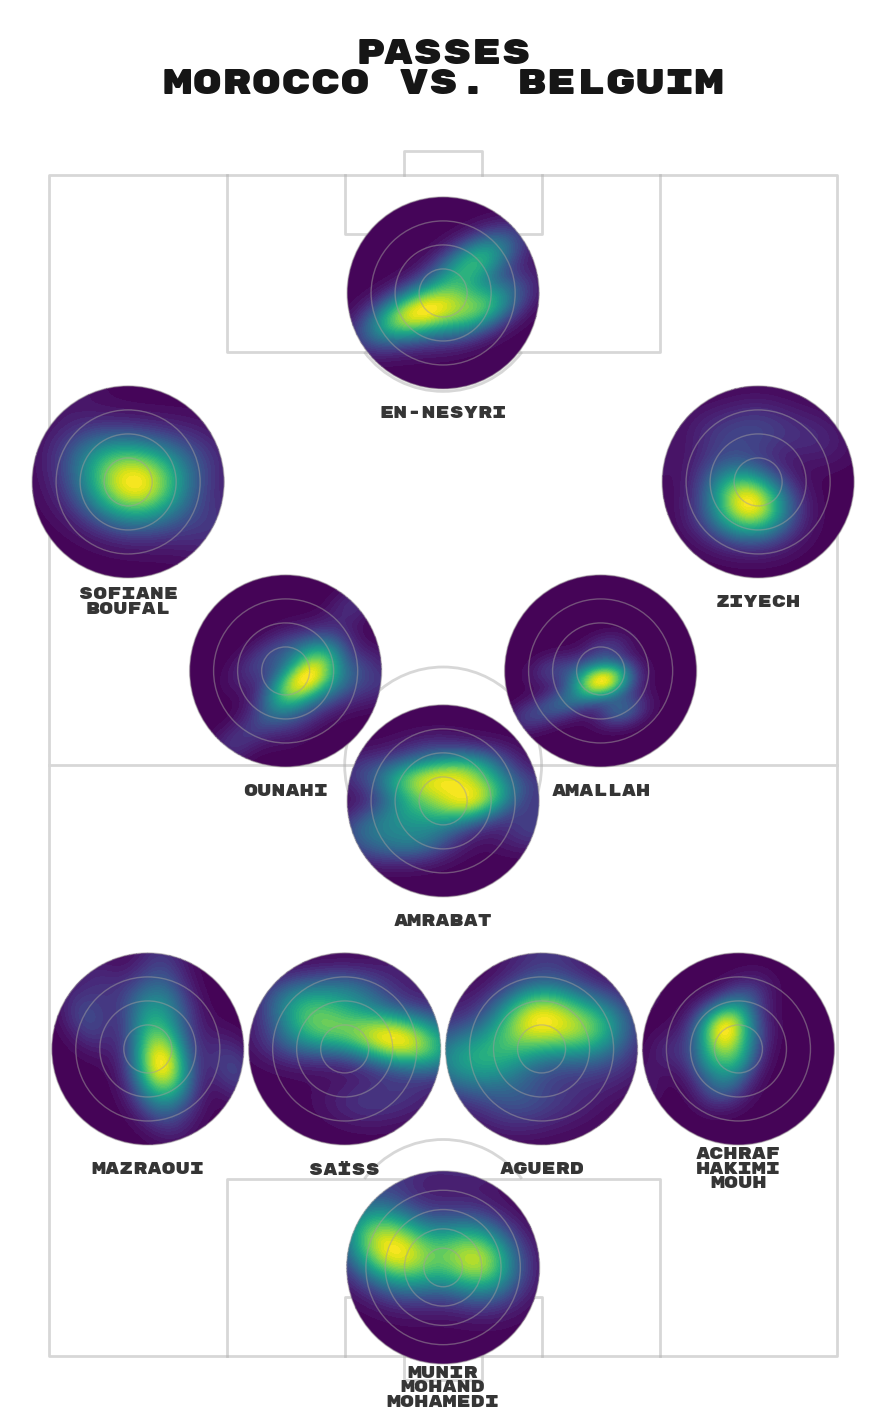

In [19]:
fig, ax = pitch.grid(endnote_height=0, title_height=0.08, figheight=14, grid_width=0.9,
                     grid_height=0.9, axis=False)
title = ax['title'].text(0.5, 0.5, 'Passes\nmorocco vs. belguim', fontsize=25,
                         va='center',
                         ha='center', color='#161616', fontproperties=fm_rubik.prop)
player_names = pitch.formation(formation, positions=starting_xi.position_id,
                               xoffset=[-15, -12, -12, -12, -12, -6, -12, -12, -12, -12, -12],
                               text=starting_xi['player_name'],
                               kind='text', va='center', ha='center', fontproperties=fm_rubik.prop,
                               fontsize=12, ax=ax['pitch'], color='#353535')
axs = pitch.formation(formation, positions=starting_xi.position_id, height=20, aspect=1,
                      xoffset=[-3, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0],
                      kind='axes', ax=ax['pitch'])

# grid for evaluating the kernel density estimator
X, Y = np.mgrid[-50:50:100j, -50:50:100j]
grid = np.vstack([X.ravel(), Y.ravel()])

for position in axs:

    # set the inset axes to square, here I made the goalkeeper larger as they tend to kick longer
    lim = 50 if position == 1 else 40
    num_lines = 5 if position == 1 else 4
    axs[position].set_xlim(-lim - 1, lim + 1)  # added some padding for plotting the last circle
    axs[position].set_ylim(-lim - 1, lim + 1)
    axs[position].axis('off')

    event_position = event[event.position_id == position].copy()
    angle_position, distance_position = pitch.calculate_angle_and_distance(event_position.x,
                                                                           event_position.y,
                                                                           event_position.end_x,
                                                                           event_position.end_y)
    x = distance_position * np.cos(angle_position)
    y = distance_position * np.sin(angle_position)
    xy = np.vstack([y, x])
    kde = gaussian_kde(xy)
    density = kde(grid).T.reshape(X.shape)

    # note on vertical pitches the kde needs to be rotated and X, Y switched
    if pitch.vertical:
        contours = axs[position].contourf(Y, X, np.rot90(density, k=3), cmap='viridis', levels=50,
                                          zorder=2)  # switch Y and X as plotted on a vertical pitch
    else:
        contours = axs[position].contourf(X, Y, density, cmap='viridis', levels=50, zorder=2)

    # add circles at intervals of ten
    for i in range(num_lines):
        lw = 3 if i == num_lines else 1  # make the last circle thicker
        circ = Circle((0, 0), (i + 1) * 10, ec='#a19e9d', lw=lw, alpha=0.5, fc='None', zorder=3)
        circ_artist = axs[position].add_artist(circ)

    # clip to the last circle
    contours.set_clip_path(circ_artist)